# PriceOracle — LSTM Model Training

This notebook trains LSTM (Long Short-Term Memory) neural network models for forecasting the closing prices of **Bitcoin (BTC-USD)** and **Ethereum (ETH-USD)**.

### Pipeline Overview
1. Fetch 5 years of historical price data from Yahoo Finance
2. Exploratory Data Analysis (EDA)
3. Preprocess and scale the data
4. Build and train the LSTM model
5. Evaluate on test set (MAE, RMSE) and compare against a baseline
6. Forecast future prices
7. Save trained models to `models/` for use by the FastAPI backend

## 1. Imports

In [1]:
from datetime import datetime, timedelta
import os
import warnings

import joblib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping

plt.style.use('fivethirtyeight')
os.makedirs('models', exist_ok=True)


I0000 00:00:1774188560.574232   73131 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774188560.664089   73131 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774188563.947736   73131 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Configuration

All key parameters are defined here so they are easy to change in one place.

- `TICKERS` — the two assets we are training on
- `YEARS` — how many years of historical data to fetch
- `BASE_DAYS` — the lookback window (how many past days the model sees to predict the next day)
- `EPOCHS` / `BATCH_SIZE` — standard neural network training hyperparameters
- `FORECAST_DAYS` — how many days ahead to predict after training

In [2]:
TICKERS       = ['BTC-USD', 'ETH-USD']
YEARS         = 5
BASE_DAYS     = 100
EPOCHS        = 20
BATCH_SIZE    = 8
FORECAST_DAYS = 10

END   = datetime.now()
START = datetime(END.year - YEARS, END.month, END.day)

## 3. Data Collection & EDA

We fetch OHLCV (Open, High, Low, Close, Volume) data from Yahoo Finance.
The model only uses the **Close** price, which is the most commonly used signal for price forecasting.

In [3]:
raw_data = {}

for ticker in TICKERS:
    data = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    raw_data[ticker] = data
    print(f'{ticker}: {len(data)} trading days fetched ({START.date()} to {END.date()})')

BTC-USD: 1827 trading days fetched (2021-03-22 to 2026-03-22)
ETH-USD: 1827 trading days fetched (2021-03-22 to 2026-03-22)


In [4]:
# Basic statistics for both assets
for ticker in TICKERS:
    print(f'\n=== {ticker} ===' )
    print(raw_data[ticker][['Close', 'Volume']].describe().round(2))


=== BTC-USD ===
Price      Close        Volume
count    1827.00  1.827000e+03
mean    55900.78  3.611017e+10
std     29758.71  2.115978e+10
min     15787.28  5.331173e+09
25%     29412.20  2.112119e+10
50%     48628.51  3.148345e+10
75%     73502.99  4.524697e+10
max    124752.53  1.817464e+11

=== ETH-USD ===
Price    Close        Volume
count  1827.00  1.827000e+03
mean   2575.10  1.915272e+10
std     889.99  1.269738e+10
min     993.64  2.081626e+09
25%    1828.33  1.015427e+10
50%    2502.35  1.629810e+10
75%    3243.56  2.394813e+10
max    4831.35  9.773662e+10


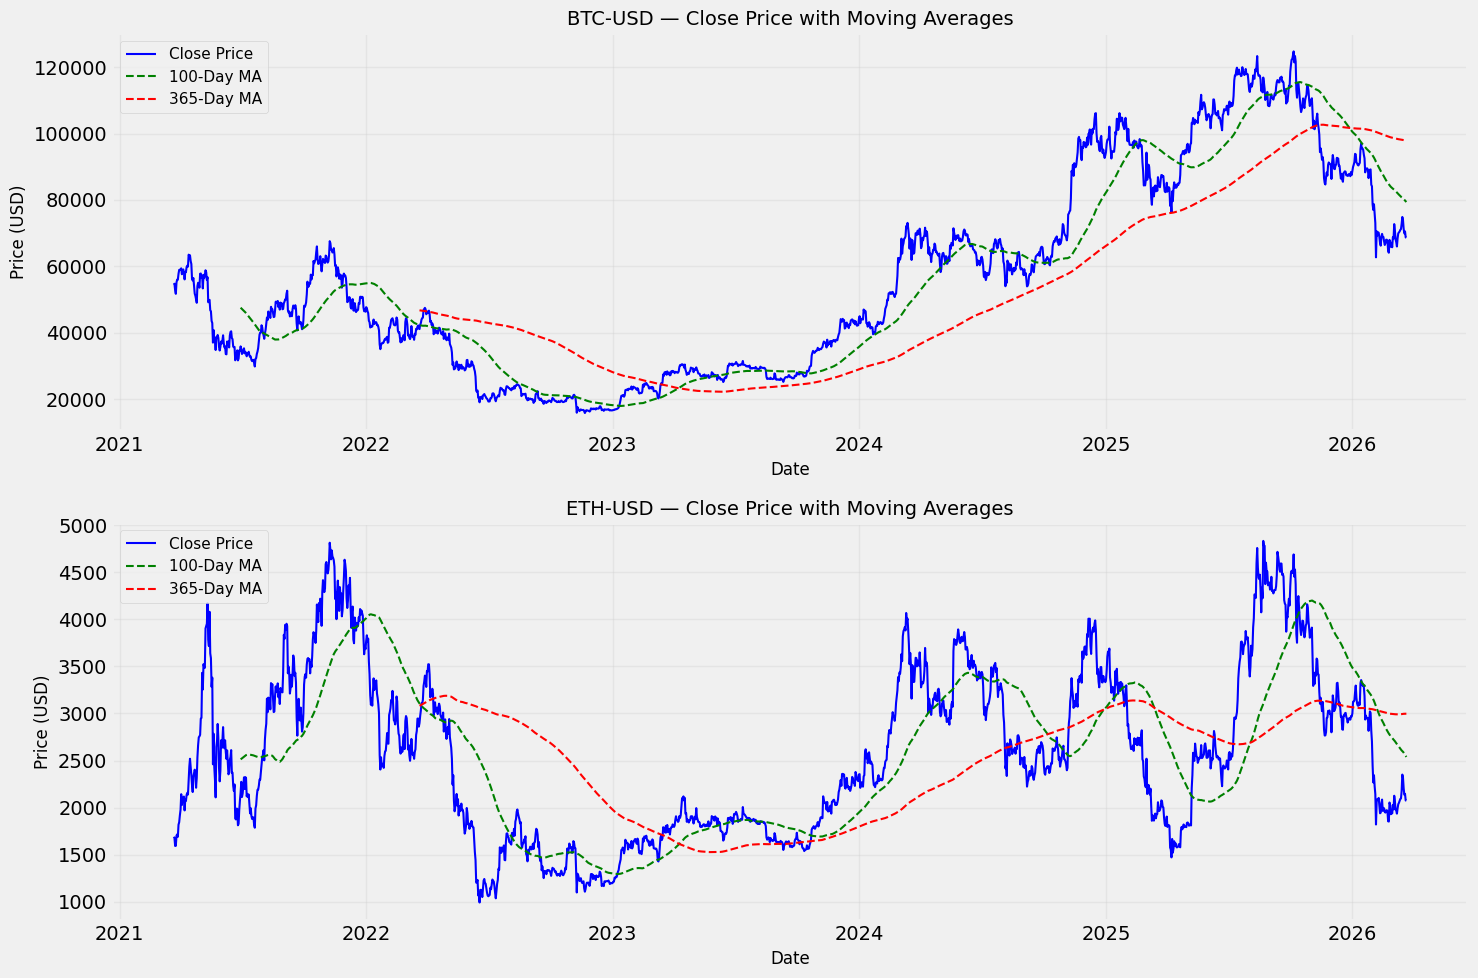

In [5]:
# Plot closing prices for both assets
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for ax, ticker in zip(axes, TICKERS):
    close = raw_data[ticker]['Close']
    ma100 = close.rolling(100).mean()
    ma365 = close.rolling(365).mean()

    ax.plot(close.index, close,  label='Close Price',  color='blue',  linewidth=1.5)
    ax.plot(close.index, ma100, label='100-Day MA',   color='green', linewidth=1.5, linestyle='--')
    ax.plot(close.index, ma365, label='365-Day MA',   color='red',   linewidth=1.5, linestyle='--')
    ax.set_title(f'{ticker} — Close Price with Moving Averages', fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

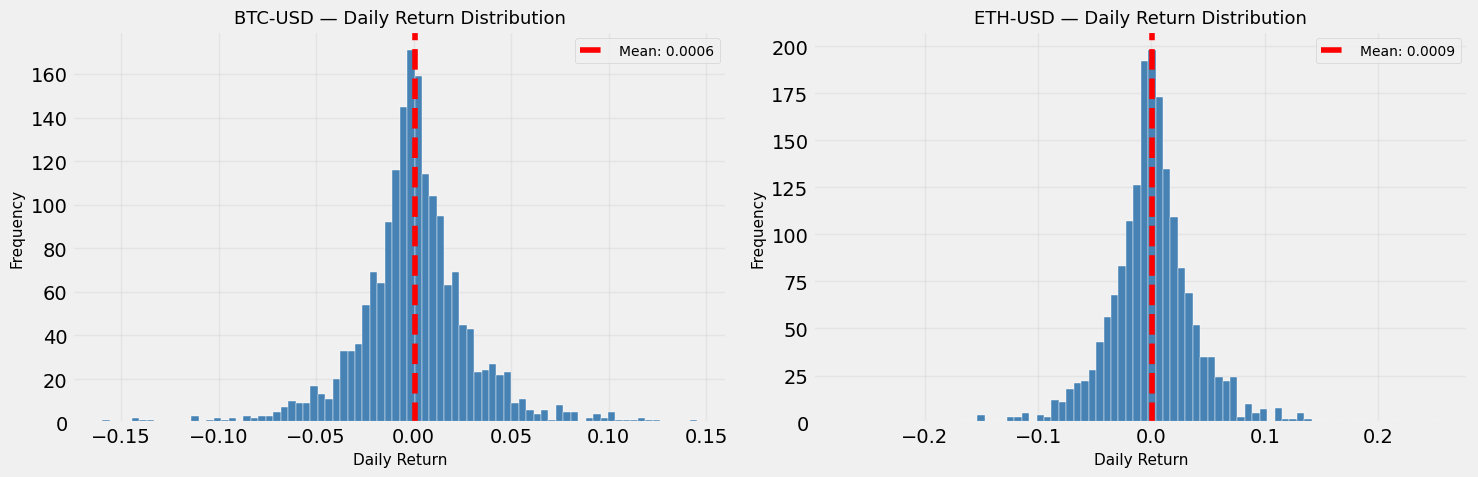

In [6]:
# Daily returns distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, ticker in zip(axes, TICKERS):
    returns = raw_data[ticker]['Close'].pct_change().dropna()
    ax.hist(returns, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{ticker} — Daily Return Distribution', fontsize=13)
    ax.set_xlabel('Daily Return', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preprocessing

### Why MinMaxScaler?
LSTM networks are sensitive to the scale of input data. Raw prices (e.g. BTC at \$80,000+) would cause very large gradients during training, slowing convergence or causing instability. We scale all values to the range **[0, 1]** using `MinMaxScaler`.

### Why BASE_DAYS = 100?
The model takes the last 100 closing prices as input to predict the next day's price. 100 days captures approximately one financial quarter of context — enough to detect short and medium-term trends without making the sequence too long.

### Train/Test Split
We use a **90/10** split — 90% of the data for training, 10% for testing. Importantly, the split is **chronological** (not random), which is required for time-series data to avoid data leakage.

In [7]:
def preprocess(ticker):
    closing = raw_data[ticker][['Close']].dropna()

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(closing)

    x_data, y_data = [], []
    for i in range(BASE_DAYS, len(scaled)):
        x_data.append(scaled[i - BASE_DAYS:i])
        y_data.append(scaled[i])

    x_data = np.array(x_data)
    y_data = np.array(y_data)

    split = int(len(x_data) * 0.9)
    x_train, y_train = x_data[:split], y_data[:split]
    x_test,  y_test  = x_data[split:], y_data[split:]

    print(f'{ticker} — Train: {len(x_train)} samples | Test: {len(x_test)} samples')
    return x_train, y_train, x_test, y_test, scaler, closing


preprocessed = {}
for ticker in TICKERS:
    preprocessed[ticker] = preprocess(ticker)

BTC-USD — Train: 1554 samples | Test: 173 samples
ETH-USD — Train: 1554 samples | Test: 173 samples


## 5. Model Architecture

We use a stacked LSTM architecture:

| Layer | Units | Notes |
|---|---|---|
| LSTM | 128 | Returns full sequence for next LSTM layer |
| Dropout | 10% | Prevents overfitting |
| LSTM | 64 | Returns final hidden state only |
| Dropout | 10% | Prevents overfitting |
| Dense | 32 | Non-linear feature combination |
| Dense | 1 | Final price prediction |

**Why LSTM?** Standard RNNs suffer from the vanishing gradient problem — they struggle to learn patterns from sequences longer than ~10 steps. LSTM cells use gating mechanisms (input, forget, output gates) to selectively retain or discard information across long sequences, making them well-suited for financial time series.

**Why two LSTM layers?** Stacking LSTM layers allows the model to learn hierarchical temporal patterns — the first layer captures short-term fluctuations, the second captures longer-term trends.

**Early Stopping** monitors validation loss and halts training if it stops improving for 3 consecutive epochs, restoring the best weights automatically.

In [8]:
def build_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(64, return_sequences=False),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

## 6. Training

In [9]:
trained_models = {}

for ticker in TICKERS:
    print(f'\n========== Training: {ticker} ==========')
    x_train, y_train, x_test, y_test, scaler, closing = preprocessed[ticker]

    model = build_model((x_train.shape[1], 1))
    model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    trained_models[ticker] = {
        'model':   model,
        'scaler':  scaler,
        'history': history,
        'closing': closing
    }
    print(f'{ticker} training complete. Epochs run: {len(history.history["loss"])}')


========== Training: BTC-USD ==========


E0000 00:00:1774188571.060275   73131 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/conceal34/Desktop/class/intel_aii/forecast/backend/myenv/lib64/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - loss: 0.0071 - val_loss: 0.0040
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 137ms/step - loss: 0.0032 - val_loss: 0.0054
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 52s 299ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 43s 244ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 209ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 9/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 217ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 39s 208ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 11/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 229ms/step - loss: 0.0012 - val_loss: 0.0045
Epoch 12/20
175/175

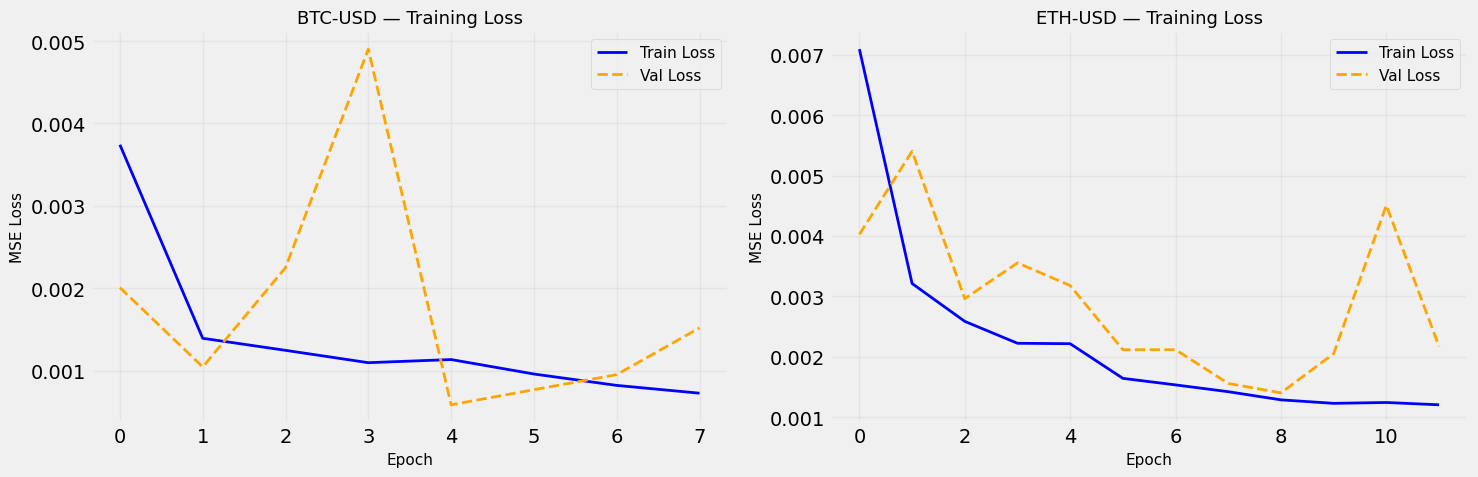

In [10]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, ticker in zip(axes, TICKERS):
    h = trained_models[ticker]['history'].history
    ax.plot(h['loss'],     label='Train Loss', color='blue',  linewidth=2)
    ax.plot(h['val_loss'], label='Val Loss',   color='orange', linewidth=2, linestyle='--')
    ax.set_title(f'{ticker} — Training Loss', fontsize=13)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation

We evaluate the model on the held-out test set using:
- **MAE (Mean Absolute Error)** — average absolute difference between predicted and actual prices (in USD). Easy to interpret directly.
- **RMSE (Root Mean Squared Error)** — penalises large errors more than MAE. Useful for catching outlier predictions.

We also compare against a **Naive Baseline** — predicting that tomorrow's price equals today's price. This is the simplest possible forecast, and any trained model should outperform it.

In [11]:
metrics_summary = []

for ticker in TICKERS:
    x_train, y_train, x_test, y_test, scaler, closing = preprocessed[ticker]
    model  = trained_models[ticker]['model']

    # Model predictions
    preds     = model.predict(x_test, verbose=0)
    inv_preds = scaler.inverse_transform(preds).flatten()
    inv_actual = scaler.inverse_transform(y_test).flatten()

    mae  = mean_absolute_error(inv_actual, inv_preds)
    rmse = np.sqrt(mean_squared_error(inv_actual, inv_preds))

    # Naive baseline: predict today's price = yesterday's price
    baseline_preds  = inv_actual[:-1]
    baseline_actual = inv_actual[1:]
    baseline_mae    = mean_absolute_error(baseline_actual, baseline_preds)
    baseline_rmse   = np.sqrt(mean_squared_error(baseline_actual, baseline_preds))

    metrics_summary.append({
        'Ticker':        ticker,
        'LSTM MAE':      round(mae, 2),
        'LSTM RMSE':     round(rmse, 2),
        'Baseline MAE':  round(baseline_mae, 2),
        'Baseline RMSE': round(baseline_rmse, 2),
    })

    trained_models[ticker]['inv_preds']  = inv_preds
    trained_models[ticker]['inv_actual'] = inv_actual

metrics_df = pd.DataFrame(metrics_summary)
print('\n=== Model Evaluation ===')
print(metrics_df.to_string(index=False))
print('\nLower MAE and RMSE = better. LSTM should outperform the naive baseline.')


=== Model Evaluation ===
 Ticker  LSTM MAE  LSTM RMSE  Baseline MAE  Baseline RMSE
BTC-USD   3139.04    4154.03       1635.03        2257.86
ETH-USD    116.81     153.95         80.18         114.45

Lower MAE and RMSE = better. LSTM should outperform the naive baseline.


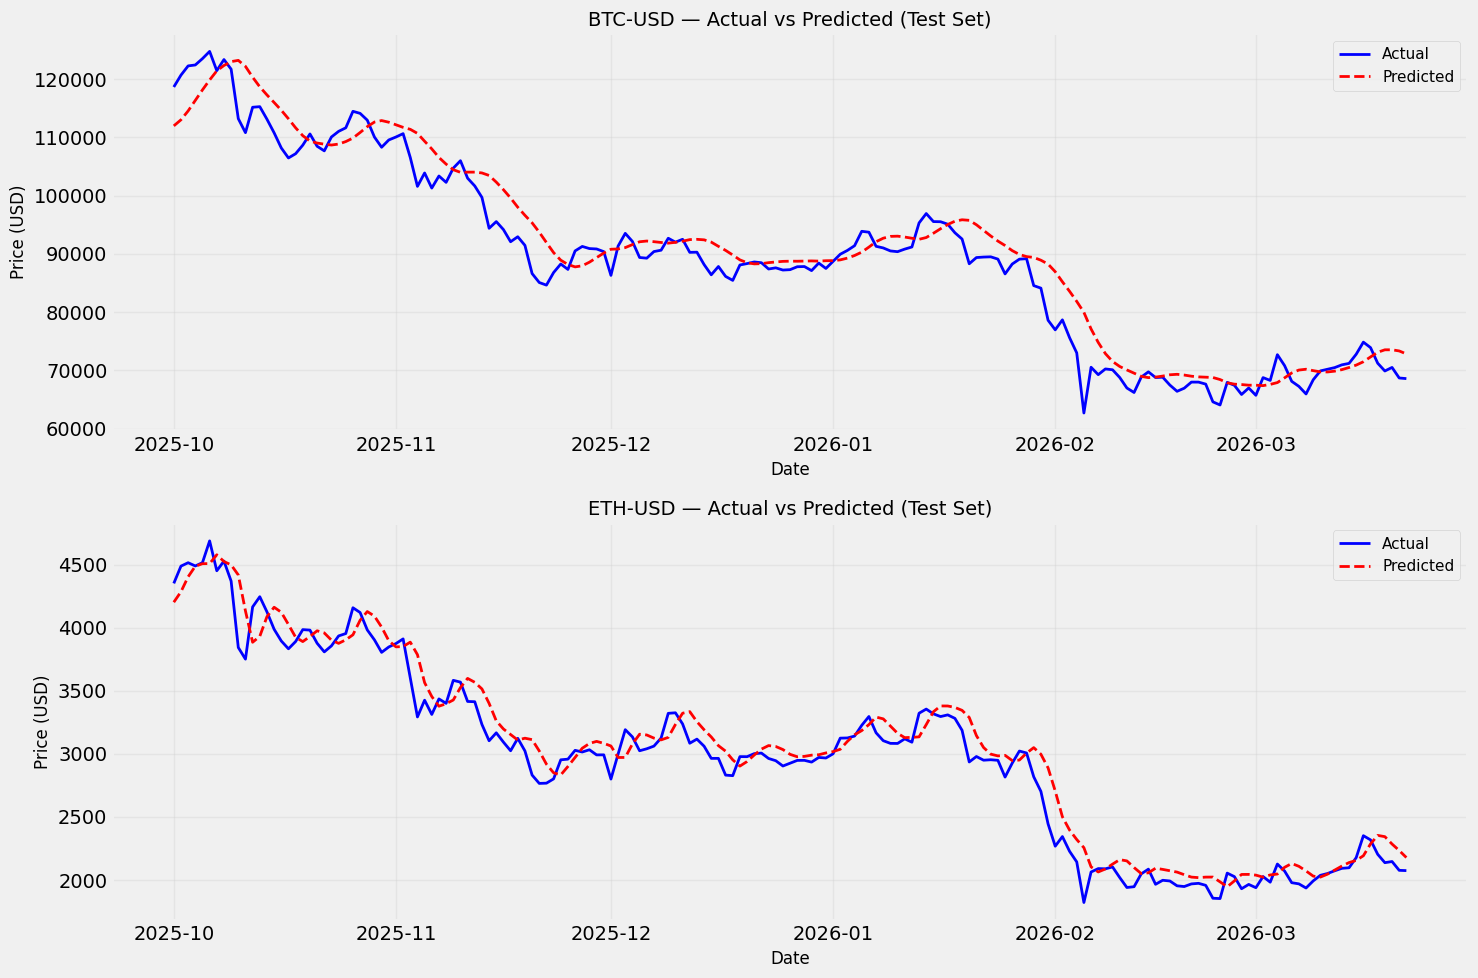

In [12]:
# Plot actual vs predicted on test set
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for ax, ticker in zip(axes, TICKERS):
    x_train, y_train, x_test, y_test, scaler, closing = preprocessed[ticker]
    split      = int(len(x_test) + len(x_train))
    test_start = len(x_train)
    test_dates = closing.index[test_start + BASE_DAYS: test_start + BASE_DAYS + len(trained_models[ticker]['inv_actual'])]

    ax.plot(test_dates, trained_models[ticker]['inv_actual'], label='Actual',    color='blue', linewidth=2)
    ax.plot(test_dates, trained_models[ticker]['inv_preds'],  label='Predicted', color='red',  linewidth=2, linestyle='--')
    ax.set_title(f'{ticker} — Actual vs Predicted (Test Set)', fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (USD)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Future Price Forecast

Using the trained model, we autoregressively predict the next `FORECAST_DAYS` days.
Each predicted price is fed back into the input window to generate the next prediction.

> ⚠️ **Disclaimer**: These forecasts are for educational purposes only and should not be used as financial advice. Cryptocurrency prices are highly volatile and unpredictable.

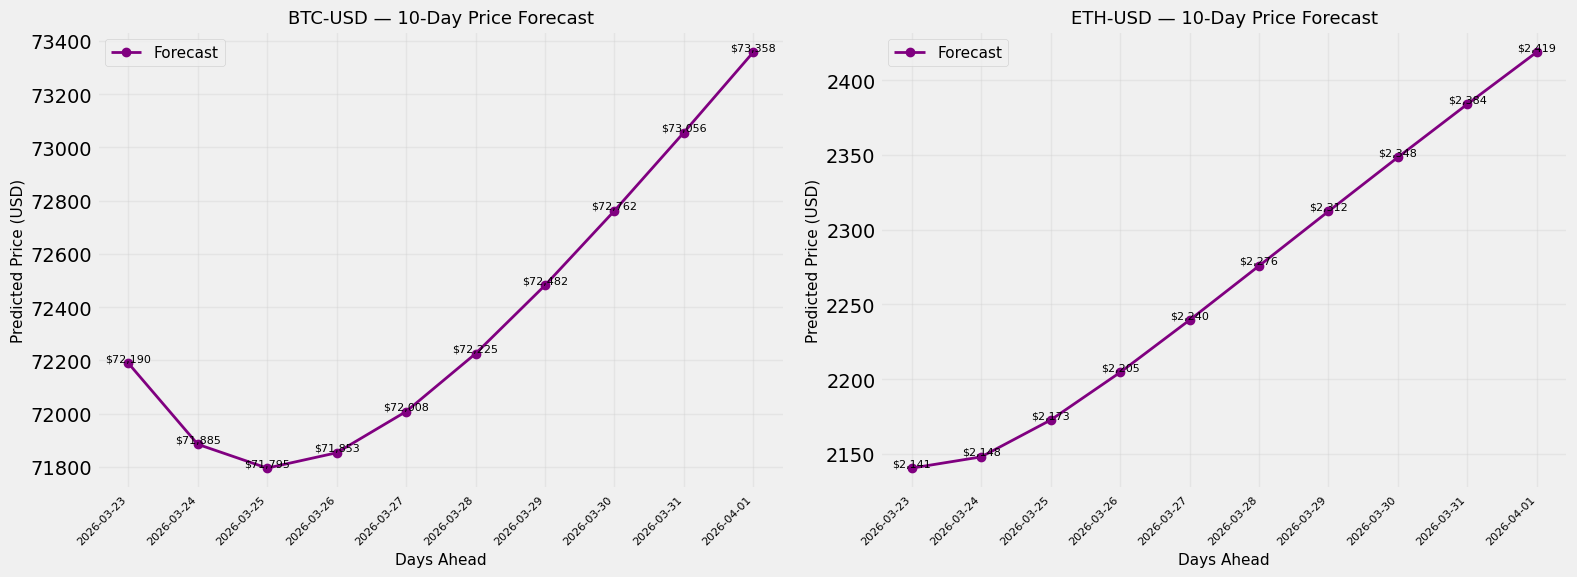

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ticker in zip(axes, TICKERS):
    x_train, y_train, x_test, y_test, scaler, closing = preprocessed[ticker]
    scaled = scaler.transform(closing)
    model  = trained_models[ticker]['model']

    last_seq      = scaled[-BASE_DAYS:].reshape(1, -1, 1)
    future_prices = []

    for _ in range(FORECAST_DAYS):
        nxt = model.predict(last_seq, verbose=0)
        future_prices.append(float(scaler.inverse_transform(nxt)[0, 0]))
        last_seq = np.append(last_seq[:, 1:, :], nxt.reshape(1, 1, 1), axis=1)

    future_dates = [
        (END + timedelta(days=i + 1)).strftime('%Y-%m-%d')
        for i in range(FORECAST_DAYS)
    ]

    ax.plot(range(1, FORECAST_DAYS + 1), future_prices, marker='o', color='purple', linewidth=2, label='Forecast')
    for i, val in enumerate(future_prices):
        ax.text(i + 1, val, f'${val:,.0f}', fontsize=8, ha='center', va='bottom')
    ax.set_title(f'{ticker} — {FORECAST_DAYS}-Day Price Forecast', fontsize=13)
    ax.set_xlabel('Days Ahead', fontsize=11)
    ax.set_ylabel('Predicted Price (USD)', fontsize=11)
    ax.set_xticks(range(1, FORECAST_DAYS + 1))
    ax.set_xticklabels(future_dates, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Models

The trained models are saved to the `models/` directory. The FastAPI backend loads these at startup and uses them directly for predictions — no retraining required at runtime.

In [14]:
for ticker in TICKERS:
    model_path  = f'models/{ticker}_lstm.keras'
    scaler_path = f'models/{ticker}_scaler.pkl'
    
    trained_models[ticker]['model'].save(model_path)
    joblib.dump(trained_models[ticker]['scaler'], scaler_path)
    
    print(f'Saved: {model_path}')
    print(f'Saved: {scaler_path}')

Saved: models/BTC-USD_lstm.keras
Saved: models/BTC-USD_scaler.pkl
Saved: models/ETH-USD_lstm.keras
Saved: models/ETH-USD_scaler.pkl
